# 09 — Catalog and Spectrum Objects

This notebook covers the core data structures of `SED_Tools`: the `Catalog` container and individual `Spectrum` objects.

**Key classes:** `Catalog`, `Spectrum`

In [1]:
from sed_tools.api import SED
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 1. The `Catalog` Object

A `Catalog` is the collection of raw spectra held in `sed.cat`. It is the counterpart to the interpolatable flux cube: the cube is for fast parameter-space queries at runtime; the catalog is for inspecting, filtering, and writing the underlying spectra.

In [2]:
try:
    sed = SED.local('Kurucz2003all')
    catalog = sed.cat
    print(f"Loaded catalog: {catalog.name}")
except Exception as e:
    print(f"Catalog not found locally: {e}")

Loaded catalog: Kurucz2003all


### Grid Axes

In [3]:
if 'catalog' in locals():
    print(f"Total spectra:     {len(catalog)}")
    print(f"Unique Teff (K):   {catalog.teff_grid}")
    print(f"Unique logg:       {catalog.logg_grid}")
    print(f"Unique [M/H]:      {catalog.metallicity_grid}")

Total spectra:     850
Unique Teff (K):   [4000. 4250. 4500. 4750. 5000. 5250. 5500. 5750. 6000. 6250. 6500. 6750.
 7000. 7250. 7500. 7750. 8000.]
Unique logg:       [3.  3.5 4.  4.5 5. ]
Unique [M/H]:      [-1.  -0.5  0.   0.2  0.5]


### Parameter Table

`catalog.parameters` returns a `pandas.DataFrame` with one row per spectrum.

In [4]:
if 'catalog' in locals():
    df = catalog.parameters
    print(f"Shape: {df.shape}")
    df.head()

Shape: (850, 4)


### Filtering

`catalog.filter()` returns a new `Catalog` containing only the spectra that match all supplied constraints.

In [5]:
if 'catalog' in locals():
    solar_subset = catalog.filter(
        teff_min=5000, teff_max=6500,
        logg_min=4.0,  logg_max=4.8,
        metallicity_min=-0.5, metallicity_max=0.5,
    )
    print(f"Solar-neighbourhood subset: {len(solar_subset)} spectra")

    cool_stars = catalog.filter(teff_max=4000)
    print(f"Cool stars (Teff ≤ 4000 K): {len(cool_stars)} spectra")

Solar-neighbourhood subset: 112 spectra
Cool stars (Teff ≤ 4000 K): 50 spectra


### Iteration

Iterating over a `Catalog` yields `Spectrum` objects.

In [6]:
if 'catalog' in locals():
    print("First 5 spectra:")
    for spec in list(catalog)[:5]:
        print(f"  Teff={spec.teff:6.0f} K  logg={spec.logg:.2f}  [M/H]={spec.metallicity:+.2f}  "
              f"file={spec.filename}")

First 5 spectra:
  Teff=  4000 K  logg=3.00  [M/H]=-0.50  file=Kurucz2003all_fid16417.txt
  Teff=  4000 K  logg=3.50  [M/H]=-0.50  file=Kurucz2003all_fid16418.txt
  Teff=  4000 K  logg=4.00  [M/H]=-0.50  file=Kurucz2003all_fid16419.txt
  Teff=  4000 K  logg=4.50  [M/H]=-0.50  file=Kurucz2003all_fid16420.txt
  Teff=  4000 K  logg=5.00  [M/H]=-0.50  file=Kurucz2003all_fid16421.txt


## 2. The `Spectrum` Object

Individual spectra are accessed by indexing the catalog. Every spectrum is guaranteed to be in standard units: wavelength in Å, flux in erg/cm²/s/Å.

In [7]:
if 'catalog' in locals():
    spec = catalog[0]

    print(f"File:       {spec.filename}")
    print(f"Teff:       {spec.teff} K")
    print(f"logg:       {spec.logg}")
    print(f"[M/H]:      {spec.metallicity}")
    print(f"Wavelength: {spec.wl[0]:.1f} – {spec.wl[-1]:.1f} Å")
    print(f"Flux range: {spec.fl.min():.2e} – {spec.fl.max():.2e} erg/cm²/s/Å")
    # .wl and .fl are aliases for .wavelength and .flux
    assert (spec.wl is spec.wavelength) and (spec.fl is spec.flux)

File:       Kurucz2003all_fid16417.txt
Teff:       4000.0 K
logg:       3.0
[M/H]:      -0.5
Wavelength: 147.2 – 1600000.0 Å
Flux range: 1.76e-159 – 1.14e+06 erg/cm²/s/Å


### Plotting a Raw Spectrum

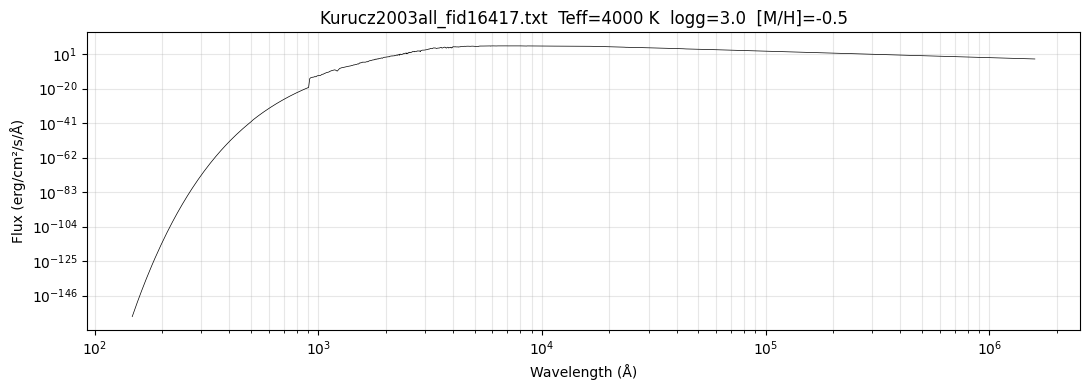

In [8]:
if 'catalog' in locals():
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.plot(spec.wl, spec.fl, lw=0.5, color='k')
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('Wavelength (Å)')
    ax.set_ylabel('Flux (erg/cm²/s/Å)')
    ax.set_title(f'{spec.filename}  Teff={spec.teff:.0f} K  logg={spec.logg}  [M/H]={spec.metallicity}')
    ax.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()

### Saving a Spectrum to Disk

In [9]:
if 'catalog' in locals():
    # spec.save('my_spectrum.txt')
    pass

## 3. Writing a Catalog to Disk

`catalog.write()` generates all MESA-compatible output files from the in-memory spectra: `flux_cube.bin`, `lookup_table.csv`, and the HDF5 bundle.

In [10]:
# output_path = catalog.write()
# print(f"Written to: {output_path}")

# Control which files are built:
# catalog.write(build_flux_cube=True, build_h5=False)